## Context 

E-Mart is a Chinese retailer that discovered the e-commerce as a way to sell to the entire world, rather than just to the population of their home city. The company has been growing without much worries, and now It wants to start using the data collected during its 4 years of e-commerce to keep growing and make more money.

Cycle 1 

The board of directors expects:

- **A Dashboard with KPIs to track their growth.**

- **Robust Data Analysis, as well as recommendation of actions. What's the actionable based on your analysis?**

- An Analysis about the countries, a segmentation by sales, profit and more. They need insights to help increasing revenue.

- Sales forecast for the next year, in order to enable strategic planning.

## Agenda


[0 Imports](#0.0-Imports)<br>
&emsp;[0.1 Helper Functions](#0.1-Helper-Functions)<br>
&emsp;[0.2 Loading Data](#0.2-Loading-Data)<br>

[1 Describe Data](#1.0-Describe-Data)<br>
&emsp;[1.1 Rename Columns](#1.1-Rename-Columns)<br>
&emsp;[1.2 Change Data Types](#1.2-Change-Data-Types)<br>
&emsp;[1.3 Feature Engineering (order_id)](#1.3-Feature-Engineering-(order_id))<br>

[2 Descriptive Statistical](#2-Descriptive-Statistical)<br>
&emsp;[2.1 Numerical Attributes](#2.1-Numerical-Attributes)<br>
&emsp;[2.2 Categorical Attributes](#2.2-Categorical-Attributes)<br>
&emsp;&emsp;[2.2.1 order_id analytical base table](#2.2.1-order_id-analytical-base-table)<br>

[3 Hypothesis Creation](#3-Hypothesis-Creation)<br>
&emsp;[3.1 Hypothesis](#3.1-Hypothesis)<br>

[4 Feature Engineering](#4-Feature-Engineering)<br>
&emsp;[cost](#cost)<br>
&emsp;[profit_per_product](#profit_per_product)<br>
&emsp;[sales_without_discount](#sales_without_discount)<br>
&emsp;[product_value](#product_value)<br>
&emsp;[product_cost](#product_cost)<br>
&emsp;[order_date year month day](#order_date-year-month-day)<br>
&emsp;[flag is_profitable_sale](#flag-is_profitable_sale)<br>

[5.0 Exploratory Data Analysis](#5.0-Exploratory-Data-Analysis)<br>
&emsp;[5.1 Univariate Analysis](#5.1-Univariate-Analysis)<br>
&emsp;&emsp;[5.1.1. Response Variable](#5.1.1.-Response-Variable)<br>
&emsp;&emsp;[5.1.2. Numerical Variables](#5.1.2.-Numerical-Variables)<br>
&emsp;&emsp;[5.1.3. Categorical Variables](#5.1.3.-Categorical-Variables)<br>
&emsp;[5.2 Bivariate Analysis](#5.2-Bivariate-Analysis)<br>
&emsp;&emsp;[KPIs](#How-do-growth-KPIs-vary?)<br>
&emsp;&emsp;&emsp;&emsp;[Revenue Growth Rate](#Revenue-Growth-Rate)<br>
&emsp;&emsp;&emsp;&emsp;[Number of Orders](#Number-of-Orders)<br>
&emsp;&emsp;&emsp;&emsp;[Conversion Rate](#Conversion-Rate)<br>
&emsp;&emsp;&emsp;&emsp;[Repurchase Rate](#Repurchase-Rate)<br>
&emsp;&emsp;&emsp;&emsp;[New Customers](#New-Customers)<br>
&emsp;&emsp;&emsp;&emsp;[Purchase Frequency](#Purchase-Frequency)<br> 
&emsp;&emsp;&emsp;&emsp;[Average Order Value](#Average-Order-Value)<br>
&emsp;&emsp;&emsp;&emsp;[Number of Active Customers](#Number-of-Active-Customers)<br>
&emsp;&emsp;&emsp;&emsp;[Churn Rate](#Churn-Rate)<br>

[Power BI Dashboard](#Power-BI-Dashboard)<br>

[Country Segmentation](#Country-Segmentation)<br>
[Sales forecast](#Sales-forecast)<br>

[Next Steps](#Next-Steps)<br>


## 0.0 Imports

In [2]:
from data_science_lib.dir import Directory, join_paths
from data_science_lib.eda import describe_data, get_categories
from data_science_lib.graph import fig

import pandas as pd
import numpy as np
import inflection
import matplotlib.pyplot as plt
import seaborn as sns

import itertools


directory = Directory("pr_v01_growth_eda", is_sub_project=True)
pd.set_option('display.max_columns', None)

%matplotlib inline

### 0.1 Helper Functions

In [3]:
def explode_column(df, column):
    return df.explode(column)

### 0.2 Loading Data

In [4]:
%%time
url = "https://raw.githubusercontent.com/pauloreisdatascience/datasets/main/superstore_dataset2011-2015.csv"
raw_data = pd.read_csv(url, encoding = "ISO-8859-1")
raw_data.head(2)

Wall time: 34.5 s


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,Algeria,NaN,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,Australia,NaN,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium


## 1.0 Describe Data

In [5]:
data = raw_data.copy()

### 1.1 Rename Columns

In [6]:
snakecase = lambda x: inflection.underscore(x).replace(" ", "_")
data.columns = map(snakecase, data.columns)
data.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority'],
      dtype='object')

> **No Duplicates.**
>
> **Postal Code has too many NaNs.** It may not affect the project, though. If needed We can try to use geolocation data (Region, State, City) to figure the missing codes out.

        To Datetime:
            order_date
            ship_date           

In [7]:
describe_data(data)

Shape: (51290, 24)
Duplicates: False


,data_types,nan_count,nan_percentage
row_id,int64,0,0.00000
order_id,object,0,0.00000
order_date,object,0,0.00000
ship_date,object,0,0.00000
ship_mode,object,0,0.00000
customer_id,object,0,0.00000
customer_name,object,0,0.00000
segment,object,0,0.00000
city,object,0,0.00000
state,object,0,0.00000


        A customer can buy many times.
        An order can have many products (database modeling).
        A product can be bought many times.

In [8]:
for col in ['row_id', 'order_id', 'customer_id', 'product_id']:
    print(col, data[col].duplicated().sum())

row_id 0
order_id 26255
customer_id 49700
product_id 40998


### 1.2 Change Data Types

**order_date** - day-month-year

In [9]:
data['order_date'][51289]

'31-12-2014'

In [10]:
data['order_date'] = pd.to_datetime(data['order_date'], infer_datetime_format=True)

**ship_date**

In [11]:
data['ship_date'] = pd.to_datetime(data['ship_date'], infer_datetime_format=True)

### 1.3 Feature Engineering (order_id)

Later I found out that there are order IDs with different customers and dates and categories...

In [12]:
data.groupby('order_id')['customer_id'].nunique().sort_values().tail()

order_id
ES-2013-3575875    3
ES-2014-3566095    4
ES-2013-4477863    4
IT-2014-1036058    4
ES-2014-4717877    4
Name: customer_id, dtype: int64

Same order_id (transaction), but different customer at a different time.

In [13]:
data[data['order_id'] == 'ES-2013-1526338'][['order_id', 'order_date', 'customer_id', 'customer_name', 'category']]

,order_id,order_date,customer_id,customer_name,category
10990,ES-2013-1526338,2013-08-03,BF-11005,Barry Franz,Office Supplies
22612,ES-2013-1526338,2013-07-14,ND-18460,Neil Ducich,Furniture
22613,ES-2013-1526338,2013-07-14,ND-18460,Neil Ducich,Office Supplies
23918,ES-2013-1526338,2013-05-15,BP-11050,Barry Pond,Technology
23957,ES-2013-1526338,2013-05-15,BP-11050,Barry Pond,Office Supplies
23959,ES-2013-1526338,2013-05-15,BP-11050,Barry Pond,Office Supplies


In [14]:
# This doesn't happen with customer_id and customer_name, thus, each customer_id has only 1 customer_name
data.groupby('customer_id')['customer_name'].nunique().sort_values().tail()

customer_id
EH-4005     1
EH-3990     1
EH-3945     1
EH-14185    1
ZD-21925    1
Name: customer_name, dtype: int64

**As a solution I'll turn order_id into order_id+customer_id**

In [15]:
data['order_id'] = data['order_id'] + "-" + data['customer_id']

## 2 Descriptive Statistical

In [16]:
numerical_attributes = data.select_dtypes( include=['int64', 'float64'] )
categorical_attributes = data.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'] )

### 2.1 Numerical Attributes

There's Negative Profit.

In average people buy 3 items? Nope, average items per Sale = 5.

In [17]:
def style_specific_cell(x):
    df = pd.DataFrame('', index=x.index, columns=x.columns)
    
    df.iloc[-2, 3] = 'background-color: lightpink'
    df.iloc[1, 5] = 'background-color: lightblue'
    df.iloc[1, 1] = 'background-color: lightgrey'   
    
    return df

data.describe().drop(columns=['row_id', 'postal_code']).T.style.apply(style_specific_cell, axis=None).format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
sales,51290.00,246.49,487.57,0.44,30.76,85.05,251.05,22638.48
quantity,51290.00,3.48,2.28,1.00,2.00,3.00,5.00,14.00
discount,51290.00,0.14,0.21,0.00,0.00,0.00,0.20,0.85
profit,51290.00,28.61,174.34,-6599.98,0.00,9.24,36.81,8399.98
shipping_cost,51290.00,26.38,57.30,0.00,2.61,7.79,24.45,933.57


This dataset is modeled as:

    order_id  product
       A         a
       A         b
       B         c
       B         a
       
So to know the actual price of an order We need to sum the price of all rows with that specific order_id

In [18]:
data.groupby('order_id')[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']].sum()\
    .describe().T.style.apply(style_specific_cell, axis=None).format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
sales,25753.00,490.91,788.79,0.56,62.09,201.31,596.73,23661.23
quantity,25753.00,6.92,5.95,1.00,3.00,5.00,9.00,58.00
discount,25753.00,0.28,0.53,0.00,0.00,0.00,0.40,9.10
profit,25753.00,56.98,270.48,-6892.37,0.00,19.56,86.76,8762.39
shipping_cost,25753.00,52.53,94.05,0.00,5.55,18.79,57.81,2076.62


### 2.2 Categorical Attributes

In [19]:
categorical_attributes.apply( lambda column: len(column.unique()) ).sort_values()

segment               3
category              3
ship_mode             4
order_priority        4
market                7
region               13
sub_category         17
country             147
customer_name       795
state              1094
customer_id        1590
city               3636
product_name       3788
product_id        10292
order_id          25753
dtype: int64

In [20]:
cols = ['segment', 'category', 'ship_mode', 'order_priority','market', 'region', 'sub_category']
get_categories(categorical_attributes[cols])

,segment,category,ship_mode,order_priority,market,region,sub_category
0,Consumer,Office Supplies,Standard Class,Medium,Africa,Africa,Storage
1,Home Office,Furniture,Second Class,High,APAC,Oceania,Supplies
2,Corporate,Technology,First Class,Critical,EMEA,EMEA,Paper
3,,,Same Day,Low,EU,North,Furnishings
4,,,,,US,Central Asia,Copiers
5,,,,,LATAM,West,Bookcases
6,,,,,Canada,North Asia,Appliances
7,,,,,,Central,Art
8,,,,,,South,Accessories
9,,,,,,Canada,Binders


#### 2.2.1 order_id analytical base table

In [21]:
aggregation = {
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean', # sum results into discounts greater than 1
    'profit': 'sum',
    'shipping_cost': 'sum',
    'segment': 'unique',
    'category': 'unique',
    'ship_mode': 'unique',
    'order_priority': 'unique',
    'market': 'unique',
    'region': 'unique',
 }
analytical_base_table = data.groupby('order_id').agg(aggregation)
analytical_base_table.head()

,sales,quantity,discount,profit,shipping_cost,segment,category,ship_mode,order_priority,market,region
order_id,,,,,,,,,,,
AE-2011-9160-PO-8865,161.082,8,0.7,-246.078,9.56,[Consumer],"[Office Supplies, Technology]",[Standard Class],[Medium],[EMEA],[EMEA]
AE-2013-1130-EB-4110,228.996,7,0.7,-236.964,60.18,[Consumer],"[Furniture, Office Supplies]",[Same Day],[High],[EMEA],[EMEA]
AE-2013-1530-MY-7380,23.634,3,0.7,-38.076,3.16,[Corporate],[Office Supplies],[Second Class],[High],[EMEA],[EMEA]
AE-2014-2840-PG-8820,42.480,1,0.7,-75.060,8.04,[Consumer],[Office Supplies],[First Class],[Critical],[EMEA],[EMEA]
AE-2014-3830-GH-4665,281.502,16,0.7,-429.108,19.38,[Consumer],"[Technology, Office Supplies]",[Standard Class],[Medium],[EMEA],[EMEA]


In [22]:
def count_unique_categories(column):
    return column.apply(lambda x: len(x))
    
analytical_base_table.select_dtypes(exclude=['int', 'float']).apply(count_unique_categories).nunique()

segment           1
category          3
ship_mode         1
order_priority    2
market            1
region            1
dtype: int64

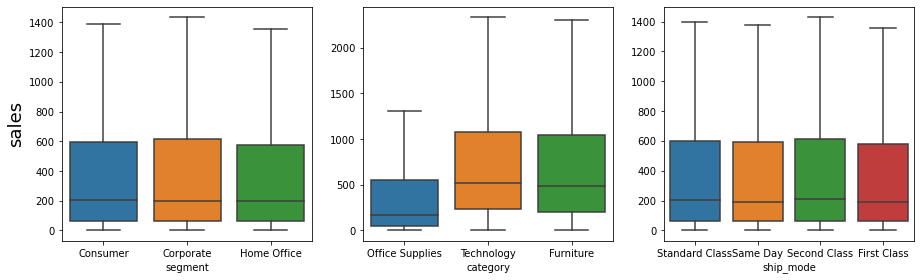

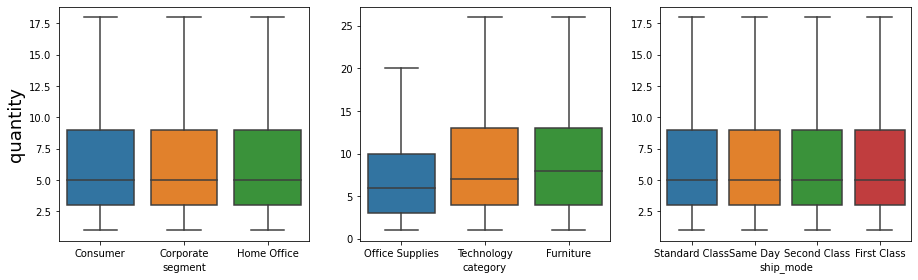

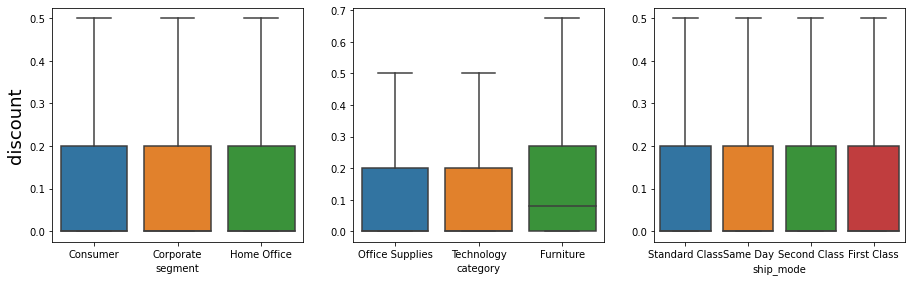

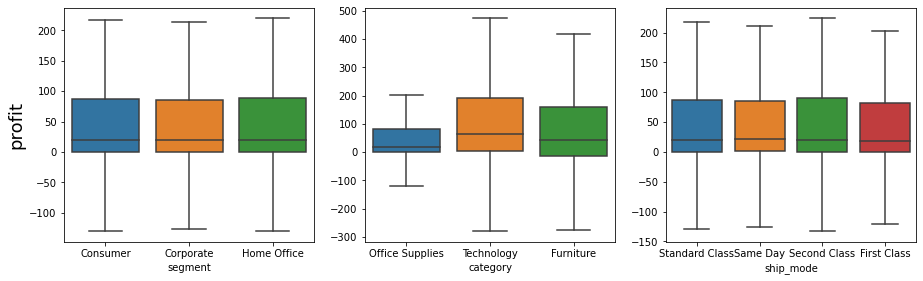

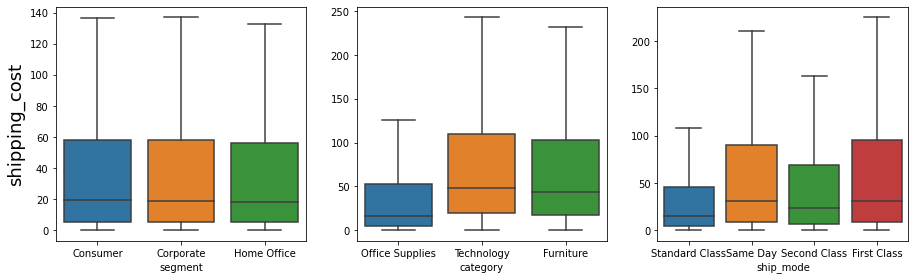

In [23]:
numerical_columns = analytical_base_table.select_dtypes(include=['int64','float64'], exclude=['bool']).columns

rows = len(numerical_columns); columns = categorical_attributes.shape[1]; plot = 0

for n_attribute in numerical_columns:
    plt.figure(figsize=(80, 25))
    
    plot += 1
    plt.subplot( rows, columns, plot )
    aux = explode_column(analytical_base_table, 'segment')
    sns.boxplot( x='segment', y = n_attribute, data=aux, showfliers=False)
    plt.ylabel(n_attribute, size=18)
    
    plot += 1
    plt.subplot( rows, columns, plot )
    aux = explode_column(analytical_base_table, 'category')
    sns.boxplot( x='category', y = n_attribute, data=aux, showfliers=False )
    plt.ylabel("")
    
    plot += 1
    plt.subplot( rows, columns, plot )
    aux = explode_column(analytical_base_table, 'ship_mode')
    sns.boxplot( x='ship_mode', y = n_attribute, data=aux, showfliers=False )
    plt.ylabel("")
    
    plt.show()

In [24]:
# Market and Region
# Similar - With some diferences in Quantity and Discount.
# Deeper look at locations later.

# for n_attribute in numerical_columns:
#     plt.figure(figsize=(120, 40))
#     plot += 1
#     plt.subplot( rows, columns, plot )
#     aux = explode_column(analytical_base_table, 'market')
#     sns.boxplot( x='market', y = n_attribute, data=data, showfliers=False)
#     plt.ylabel(n_attribute, size=18)
#     plot += 1
#     plt.subplot( rows, columns, plot )
#     aux = explode_column(analytical_base_table, 'region')
#     sns.boxplot( x='region', y = n_attribute, data=data, showfliers=False )
#     plt.ylabel("")

#     plt.show()

## 3 Hypothesis Creation

### Growth KPIs

[e-commerce growth KPIs](https://www.google.com/search?q=growth+KPIs+ecommerce&rlz=1C1GCEA_enBR944BR944&sxsrf=AOaemvIUIxkEh1kD_kv_q9GajXU_aS6heA%3A1635545511924&ei=p3F8YfWqN9-r1sQPhsWfmA8&oq=growth+KPIs+ecommerce&gs_lcp=Cgdnd3Mtd2l6EAMyBwghEAoQoAEyBAghEBU6BwgjELADECc6BwgAEEcQsAM6BggAEBYQHjoFCCEQoAE6CAghEBYQHRAeSgQIQRgAUKs4WJ9CYL1DaAFwAngAgAGTAogBsg2SAQUwLjcuMpgBAKABAcgBCcABAQ&sclient=gws-wiz&ved=0ahUKEwi1moHq0fDzAhXflZUCHYbiB_MQ4dUDCA4&uact=5)


[**Revenue Growth Rate**](#Revenue-Growth-Rate)<br>

&emsp;How fast are We growing?<br>
&emsp;_Yearly. Monthly._<br>



[**Number of Orders**](#Number-of-Orders)<br>

&emsp;_Monthly_<br>



[**Conversion Rate**](#Conversion-Rate)<br>

&emsp;How many potential customers are We losing?<br>
&emsp;_Monthly_<br>



[**Repurchase Rate**](#Repurchase-Rate)<br>

&emsp;How many customers keep purchasing? (Loyalty KPI)<br>
&emsp;_Monthly_<br>


[4 kpis capture success of retail loyalty program](https://www.cheetahdigital.com/blog/4-kpis-capture-success-your-retail-loyalty-program)



[**New Customers**](#New-Customers)<br>

&emsp;Number of New Customers each month.<br>



[**Purchase Frequency**](#Purchase-Frequency)<br>

&emsp;Average number of orders per customer.<br>



[**Average Order Value**](#Average-Order-Value)

&emsp;_Monthly_<br>


[**Number of Active Customers**](#Number-of-Active-Customers)

&emsp;


[**Churn Rate**](#Churn-Rate)<br>

&emsp;How many customers are We losing?<br>
&emsp;_Monthly_<br>


## Products

[**Which products has more sales?**](#)

[**Which ones are most profitable?**](#)

[**What about their categories?**](#)

## 4 Feature Engineering

In [25]:
df = data.copy()

        One problem We have is the lack of metadata to explain what each variable means.
        Example: here we know that if we aggregate this order we can't sum the discounts
        (discount of 140%?), but what about shipping_cost?

In [26]:
df[df['order_id'] == 'AE-2011-9160'][['order_id','sales','discount','shipping_cost']]

,order_id,sales,discount,shipping_cost


        
        About price formation... Is "sales" the value with or without the discount? 
        Is "shipping_cost" included in it? Etc...
        
**Therefore, I'll estimate some new features based on profit formula, and making some assumptions.**

        Profit = [Sales] - [Cost]
        
        I'm assuming that "sales" is the value with discount and that the shipping cost is already
        included in "sales", as well as the "profit".
        
        Price formation:       
            Sale Value = ( (product_value*quantity) * discount ) + shipping

In [27]:
sample = data.sample()
display(sample[['sales', 'quantity', 'discount', 'profit', 'shipping_cost']])
print()

sales         = sample['sales'].values[0]
discount      = sample['discount'].values[0]
quantity      = sample['quantity'].values[0]
profit        = sample['profit'].values[0]
shipping_cost = sample['shipping_cost'].values[0]

costs = sales - profit - shipping_cost
if discount == 0:
    sales_without_discount = (sales-shipping_cost) + shipping_cost
else:
    sales_without_discount = ( (sales-shipping_cost)/( discount ) ) + shipping_cost # (1-discount ) TO AVOID DIVISION BY 0
product_value = ( sales_without_discount - shipping_cost )/quantity
profit_per_product = profit / quantity
product_cost = product_value - profit_per_product


print(f"                costs: {round(costs, 2)}\t\tsales - profit - shipping_cost")
print()
print(f"sale_without_discount: {round(sales_without_discount, 2)}\t\t( (sales-shipping_cost)/( 1-discount ) ) + shipping_cost")
print()
print(f"     product_quantity: {round(quantity, 2)}")
print(f"        product_value: {round(product_value, 2)}\t\t( sales_without_discount - shipping_cost )/quantity")
print(f"   profit_per_product: {round(profit_per_product, 2)}\t\tprofit / quantity")
print(f"         product_cost: {round(product_cost, 2)}\t\tproduct_value - profit_per_product")

print()
print(f"            -discount: {round(discount, 2)}")
print(f"       +shipping_cost: {round(shipping_cost, 2)}")
print()
if discount == 0:
    price = (product_value*quantity) + shipping_cost
else:
    price = (     (product_value*quantity)*(discount)     ) + shipping_cost
print(f'                Price: {price}\t\t( (product_value*quantity)*(discount) ) + shipping_cost')

,sales,quantity,discount,profit,shipping_cost
10377,1466.88,8,0.0,219.84,85.35



                costs: 1161.69		sales - profit - shipping_cost

sale_without_discount: 1466.88		( (sales-shipping_cost)/( 1-discount ) ) + shipping_cost

     product_quantity: 8
        product_value: 172.69		( sales_without_discount - shipping_cost )/quantity
   profit_per_product: 27.48		profit / quantity
         product_cost: 145.21		product_value - profit_per_product

            -discount: 0.0
       +shipping_cost: 85.35

                Price: 1466.88		( (product_value*quantity)*(discount) ) + shipping_cost


### cost

> **The cost of that sale to the company.**

In [28]:
df['cost'] = df['sales'] - df['profit'] - df['shipping_cost']

### profit_per_product

In [29]:
df['profit_per_product'] = df['profit'] / df['quantity']

### sales_without_discount

In [30]:
def _calculate_sales_without_discount(row):
    if row['discount'] == 0:
        sales_without_discount = (row['sales'] - row['shipping_cost'] ) + row['shipping_cost']
    else:
        sales_without_discount = ((row['sales'] - row['shipping_cost'] ) / row['discount']) + row['shipping_cost']
    return sales_without_discount

In [31]:
df['sales_without_discount'] = df.apply(_calculate_sales_without_discount, axis=1)

### product_value

> **Sale value of an unity of the product**

In [32]:
df['product_value'] = (df['sales_without_discount'] - df['shipping_cost']) / df['quantity']

### product_cost

In [33]:
df['product_cost'] = df['product_value'] - df['profit_per_product']

### order_date year month day

In [34]:
df['order_date_year'] = df['order_date'].dt.year
df['order_date_month'] = df['order_date'].dt.month
df['order_date_day'] = df['order_date'].dt.day

### flag is_profitable_sale

> **There are profit with negative values, in other words, deficit.**

In [35]:
df['is_profitable_sale'] = df['profit'].apply(lambda x: 1 if x > 0 else 0)

## 5.0 Exploratory Data Analysis

In [36]:
# temporary_desc = describe_data(df)
# temporary_desc

In [37]:
df.to_parquet(join_paths([directory.DATA_DIR, 'processed', 'e_mart_data.parquet']))

In [38]:
df.to_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', 'e_mart_data.csv']), index=False)

In [39]:
aggregation = {
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'shipping_cost': 'sum',
    'cost': 'sum',
    'profit_per_product': 'sum',
    'sales_without_discount': 'sum',
    'product_value':'sum',
    'product_cost': 'sum',
    'order_date': 'max',
    'order_date_year': 'max',
    'is_profitable_sale': 'mean',
    'customer_id': 'unique',
    'segment': 'unique',
    'category': 'unique',
    'ship_mode': 'unique',
    'order_priority': 'unique',
    'market': 'unique',
    'region': 'unique',
 }
analytical_base_table = df.groupby('order_id').agg(aggregation)
analytical_base_table.head()

,sales,quantity,discount,profit,shipping_cost,cost,profit_per_product,sales_without_discount,product_value,product_cost,order_date,order_date_year,is_profitable_sale,customer_id,segment,category,ship_mode,order_priority,market,region
order_id,,,,,,,,,,,,,,,,,,,,
AE-2011-9160-PO-8865,161.082,8,0.7,-246.078,9.56,397.60,-93.375,226.020000,72.735714,166.110714,2011-03-10,2011,0.0,[PO-8865],[Consumer],"[Office Supplies, Technology]",[Standard Class],[Medium],[EMEA],[EMEA]
AE-2013-1130-EB-4110,228.996,7,0.7,-236.964,60.18,405.78,-43.404,301.345714,45.132381,88.536381,2013-10-14,2013,0.0,[EB-4110],[Consumer],"[Furniture, Office Supplies]",[Same Day],[High],[EMEA],[EMEA]
AE-2013-1530-MY-7380,23.634,3,0.7,-38.076,3.16,58.55,-23.340,32.408571,18.350000,41.690000,2013-12-31,2013,0.0,[MY-7380],[Corporate],[Office Supplies],[Second Class],[High],[EMEA],[EMEA]
AE-2014-2840-PG-8820,42.480,1,0.7,-75.060,8.04,109.50,-75.060,57.240000,49.200000,124.260000,2014-05-11,2014,0.0,[PG-8820],[Consumer],[Office Supplies],[First Class],[Critical],[EMEA],[EMEA]
AE-2014-3830-GH-4665,281.502,16,0.7,-429.108,19.38,691.23,-239.424,393.840000,187.562143,426.986143,2014-12-13,2014,0.0,[GH-4665],[Consumer],"[Technology, Office Supplies]",[Standard Class],[Medium],[EMEA],[EMEA]


In [40]:
analytical_base_table['segment'] = analytical_base_table['segment'].apply(lambda x: x[0] if len(x)==1 else None)
analytical_base_table['ship_mode'] = analytical_base_table['ship_mode'].apply(lambda x: x[0] if len(x)==1 else None)
analytical_base_table['order_priority'] = analytical_base_table['order_priority'].apply(lambda x: x[0] if len(x)==1 else None)
analytical_base_table['market'] = analytical_base_table['market'].apply(lambda x: x[0] if len(x)==1 else None)
analytical_base_table['region'] = analytical_base_table['region'].apply(lambda x: x[0] if len(x)==1 else None)
analytical_base_table['customer_id'] = analytical_base_table['customer_id'].apply(lambda x: x[0] if len(x)==1 else None)

# analytical_base_table['category'].apply(lambda x: x[0] if len(x)==1 else len(x)).value_counts()

In [41]:
analytical_base_table.reset_index().to_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', 'orders_abt.csv']), index=False)

In [42]:
aggregation = {
    'sales': 'sum',
    'quantity': 'sum',
    'discount': 'mean',
    'profit': 'sum',
    'shipping_cost': 'sum',
    'cost': 'sum',
    'profit_per_product': 'sum',
    'sales_without_discount': 'sum',
    'product_value':'sum',
    'product_cost': 'sum',
    'order_date': 'max',
    'order_date_year': 'max',
    'is_profitable_sale': 'mean',
    'customer_id': 'unique',
    'segment': 'unique',
    'category': 'unique',
    'ship_mode': 'unique',
    'order_priority': 'unique',
    'market': 'unique',
    'region': 'unique',
 }

aa = analytical_base_table.reset_index().groupby('customer_id')[['sales', 'order_date_year']].agg({'sales':'mean','order_date_year':'max'})#.agg(aggregation)

In [43]:
aa[aa.order_date_year==2014].mean()

sales               436.764777
order_date_year    2014.000000
dtype: float64

In [44]:
analytical_base_table

,sales,quantity,discount,profit,shipping_cost,cost,profit_per_product,sales_without_discount,product_value,product_cost,order_date,order_date_year,is_profitable_sale,customer_id,segment,category,ship_mode,order_priority,market,region
order_id,,,,,,,,,,,,,,,,,,,,
AE-2011-9160-PO-8865,161.082,8,0.7,-246.078,9.56,397.60,-93.375,226.020000,72.735714,166.110714,2011-03-10,2011,0.0,PO-8865,Consumer,"[Office Supplies, Technology]",Standard Class,Medium,EMEA,EMEA
AE-2013-1130-EB-4110,228.996,7,0.7,-236.964,60.18,405.78,-43.404,301.345714,45.132381,88.536381,2013-10-14,2013,0.0,EB-4110,Consumer,"[Furniture, Office Supplies]",Same Day,High,EMEA,EMEA
AE-2013-1530-MY-7380,23.634,3,0.7,-38.076,3.16,58.55,-23.340,32.408571,18.350000,41.690000,2013-12-31,2013,0.0,MY-7380,Corporate,[Office Supplies],Second Class,High,EMEA,EMEA
AE-2014-2840-PG-8820,42.480,1,0.7,-75.060,8.04,109.50,-75.060,57.240000,49.200000,124.260000,2014-05-11,2014,0.0,PG-8820,Consumer,[Office Supplies],First Class,Critical,EMEA,EMEA
AE-2014-3830-GH-4665,281.502,16,0.7,-429.108,19.38,691.23,-239.424,393.840000,187.562143,426.986143,2014-12-13,2014,0.0,GH-4665,Consumer,"[Technology, Office Supplies]",Standard Class,Medium,EMEA,EMEA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZI-2014-7160-EH-4125,51.075,4,0.7,-96.135,3.72,143.49,-82.332,71.370000,56.432857,138.764857,2014-10-30,2014,0.0,EH-4125,Home Office,[Office Supplies],First Class,Medium,Africa,Africa
ZI-2014-7610-BS-1380,25.578,2,0.7,-30.312,2.34,53.55,-30.312,35.537143,33.197143,63.509143,2014-03-24,2014,0.0,BS-1380,Corporate,"[Technology, Office Supplies]",Standard Class,Medium,Africa,Africa
ZI-2014-9540-BT-1395,7.164,2,0.7,-6.696,0.35,13.51,-3.348,10.084286,4.867143,8.215143,2014-09-06,2014,0.0,BT-1395,Corporate,[Office Supplies],Standard Class,Medium,Africa,Africa


In [45]:
numerical_attributes = analytical_base_table.select_dtypes( include=['int64', 'float64'] )
categorical_attributes = analytical_base_table.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'] )

### 5.1 Univariate Analysis
#### 5.1.1. Response Variable

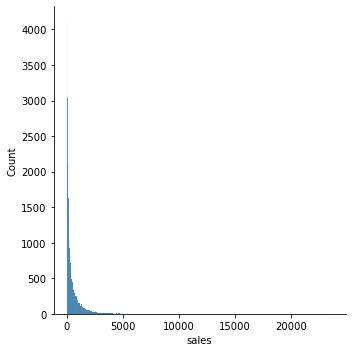

In [46]:
sns.displot(analytical_base_table['sales']);

In [47]:
analytical_base_table[['sales']].agg(['mean', 'median'])

,sales
mean,490.913754
median,201.312000


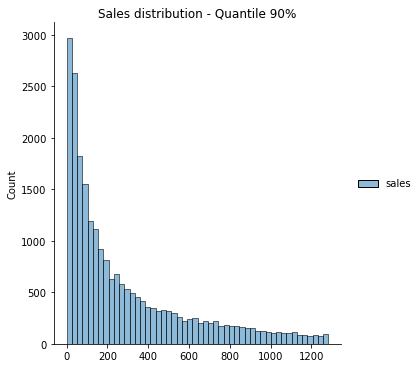

In [48]:
aux = analytical_base_table[['sales']]
sns.displot(aux[aux <= aux.quantile(.90)])
plt.title("Sales distribution - Quantile 90%");

#### 5.1.2. Numerical Variables

        days_for_shipping
            Negative values, which means that probabily ship_date was incorrectly converted to datetime. 
            Go back and fix it if needed.

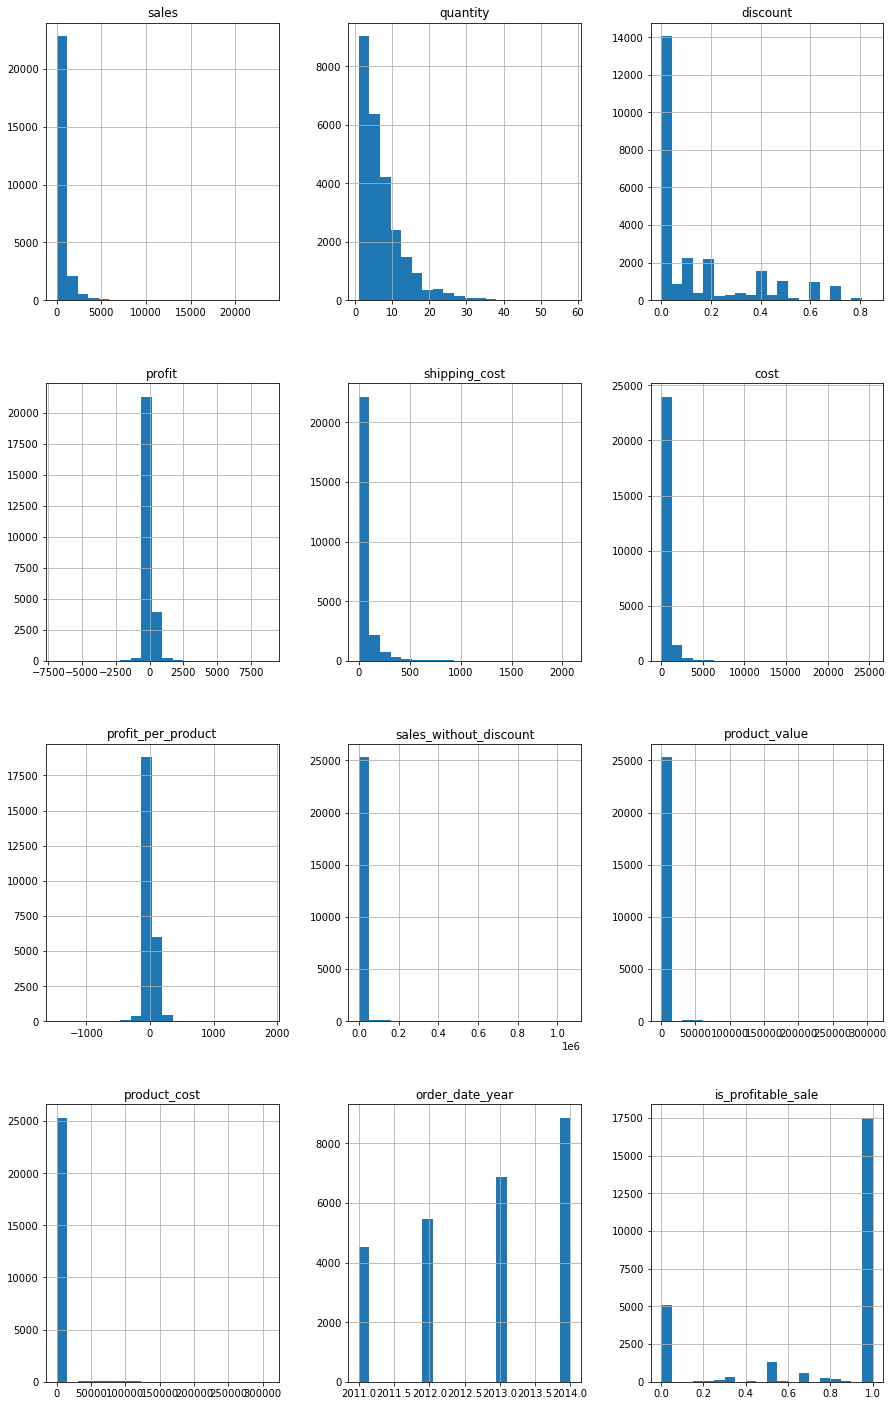

In [49]:
rows = int(np.ceil( numerical_attributes.shape[1]/3 ))
numerical_attributes.hist(figsize=(15,25), layout=(rows, 3), bins=20);

### 5.1.3. Categorical Variables

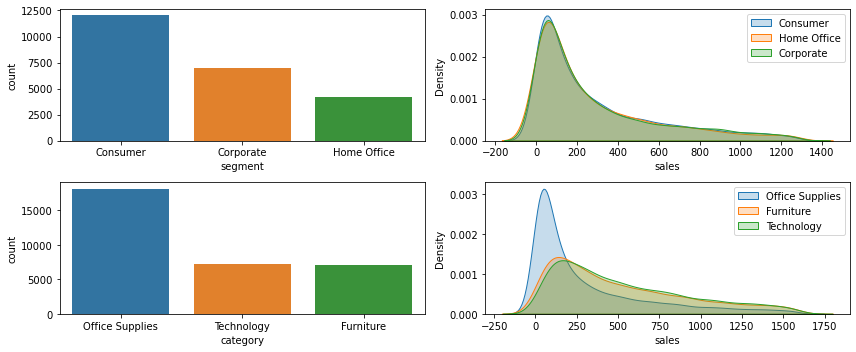

In [50]:
y_variable = 'sales'
aux = explode_column(analytical_base_table, 'segment')
aux = aux[aux[y_variable] < aux[y_variable].quantile(.90)]

fig(12)

plt.subplot( 2, 2, 1 )
sns.countplot(x=aux['segment'])

plt.subplot( 2, 2, 2 )
sns.kdeplot(aux[aux['segment'] == 'Consumer'][y_variable], label='Consumer', shade=True)
sns.kdeplot(aux[aux['segment'] == 'Home Office'][y_variable], label='Home Office', shade=True)
sns.kdeplot(aux[aux['segment'] == 'Corporate'][y_variable], label='Corporate', shade=True)
plt.legend()


aux = explode_column(analytical_base_table, 'category')
aux = aux[aux[y_variable] < aux[y_variable].quantile(.90)]

plt.subplot(2, 2, 3 )
sns.countplot(x=aux['category'])

plt.subplot( 2, 2, 4 )
sns.kdeplot(aux[aux['category'] == 'Office Supplies'][y_variable], label='Office Supplies', shade=True)
sns.kdeplot(aux[aux['category'] == 'Furniture'][y_variable], label='Furniture', shade=True)
sns.kdeplot(aux[aux['category'] == 'Technology'][y_variable], label='Technology', shade=True)
plt.legend()

plt.tight_layout()

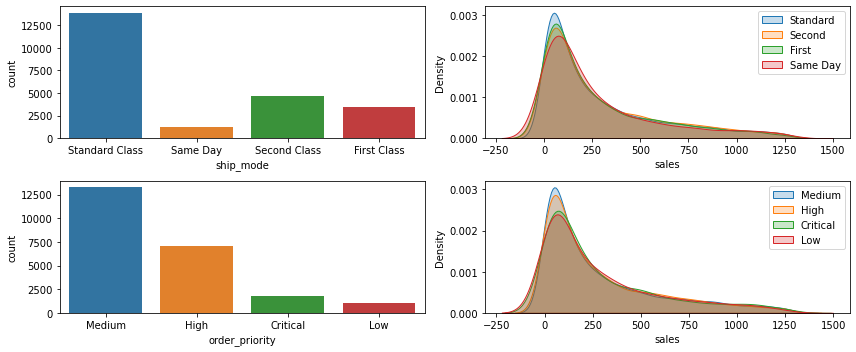

In [51]:
aux = explode_column(analytical_base_table, 'ship_mode')
aux = aux[aux[y_variable] < aux[y_variable].quantile(.90)]

fig(12)

plt.subplot( 2, 2, 1 )
sns.countplot(x=aux['ship_mode'])

plt.subplot( 2, 2, 2 )
sns.kdeplot(aux[aux['ship_mode'] == 'Standard Class'][y_variable], label='Standard', shade=True)
sns.kdeplot(aux[aux['ship_mode'] == 'Second Class'][y_variable], label='Second', shade=True)
sns.kdeplot(aux[aux['ship_mode'] == 'First Class'][y_variable], label='First', shade=True)
sns.kdeplot(aux[aux['ship_mode'] == 'Same Day'][y_variable], label='Same Day', shade=True)
plt.legend()


aux = explode_column(analytical_base_table, 'order_priority')
aux = aux[aux[y_variable] < aux[y_variable].quantile(.90)]

plt.subplot(2, 2, 3 )
sns.countplot(x=aux['order_priority'])

plt.subplot( 2, 2, 4 )
sns.kdeplot(aux[aux['order_priority'] == 'Medium'][y_variable], label='Medium', shade=True)
sns.kdeplot(aux[aux['order_priority'] == 'High'][y_variable], label='High', shade=True)
sns.kdeplot(aux[aux['order_priority'] == 'Critical'][y_variable], label='Critical', shade=True)
sns.kdeplot(aux[aux['order_priority'] == 'Low'][y_variable], label='Low', shade=True)
plt.legend()

plt.tight_layout()

### 5.2 Bivariate Analysis

### How do growth KPIs vary?

### Revenue Growth Rate

How fast We are growing.

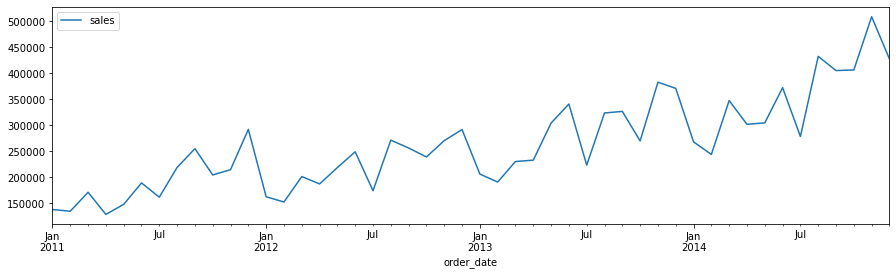

In [52]:
df.groupby("order_date")[['sales']].sum().round(2).resample("m").sum().plot(figsize=(15, 4));

In [53]:
aux = df.groupby("order_date_year")[['sales']].sum()
aux['revenue_growth_rate'] = aux['sales'].pct_change().fillna(0)*100
aux.round(2)

,sales,revenue_growth_rate
order_date_year,,
2011,2259450.90,0.00
2012,2677438.69,18.50
2013,3405746.45,27.20
2014,4299865.87,26.25


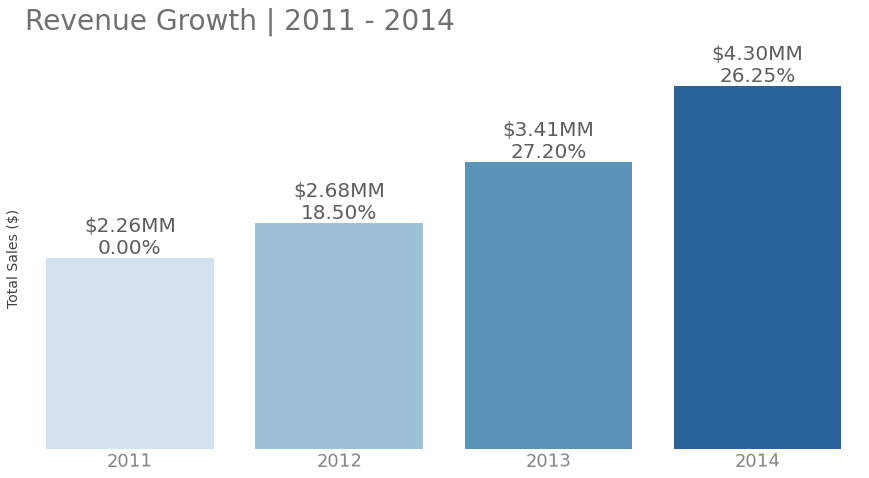

In [54]:
fig(15, 7)
sns.barplot(x=aux.index, y='sales', palette='Blues', data=aux)

plt.box(False)
plt.title(f"Revenue Growth | 2011 - 2014\n", fontsize=28, color='#707070', loc='left')
plt.tick_params(axis='both', which='both', length=0)
plt.xlabel(None)
plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xticks(color="#838383", rotation=.9, size=18)
plt.yticks([],[])

x = list(range(len(aux)))
growth_rate = aux['revenue_growth_rate'].values
sales = aux['sales'].values
for sale_value, rate in zip(range(len(sales)), growth_rate):
    plt.annotate("${:,.2f}MM\n{:,.2f}%".format(sales[sale_value]/1000000, growth_rate[sale_value]),
                 xy=(x[sale_value],sales[sale_value]),
                 ha='center', va='bottom', size=20, color='#5d5d5d') #color='#03396c'

**Monthly**

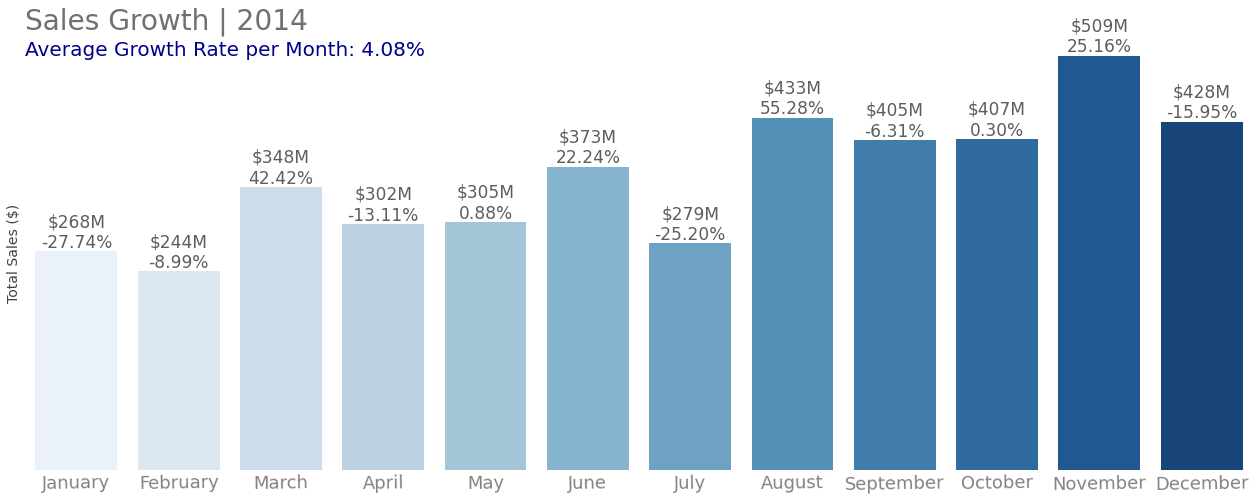

In [100]:
aux = df[df['order_date_year'] == 2014].groupby("order_date")[['sales']].sum().resample("m").sum()
aux['revenue_growth_rate'] = aux['sales'].pct_change().fillna(-0.2774)*100
avg_growth_rate = round(aux['revenue_growth_rate'].mean(), 2)

fig(22, 8)
sns.barplot(data=aux, x=aux.index.month_name(), y='sales', palette='Blues')

plt.box(False)
plt.title(f"Sales Growth | 2014", fontsize=28, color='#707070', loc='left')
plt.text(-0.5, 510000, f"Average Growth Rate per Month: {avg_growth_rate}%", color='#00008b', size=20);
plt.tick_params(axis='both', which='both', length=0)
plt.xlabel(None)
plt.ylabel("Total Sales ($)", size=14, color='#424242')
plt.xticks( color="#838383", rotation=.9, size=18)
plt.yticks([],[])

x = list(range(len(aux)))
growth_rate = aux['revenue_growth_rate'].values
sales = aux['sales'].values
for sale_value, rate in zip(range(len(sales)), growth_rate):
    plt.annotate("${:,.0f}M\n{:,.2f}%".format(sales[sale_value]/1000, growth_rate[sale_value]),
                 xy=(x[sale_value],sales[sale_value]),
                 ha='center', va='bottom', size=17, color='#5d5d5d') #color='#03396c'

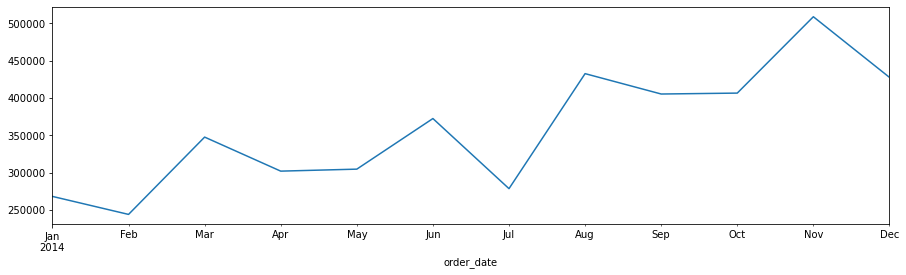

In [56]:
aux['sales'].plot(figsize=(15, 4));

### Number of Orders

In [57]:
aux = df.groupby("order_date")[['order_id']].nunique().resample("M").sum()
aux.columns = ['number_of_orders']

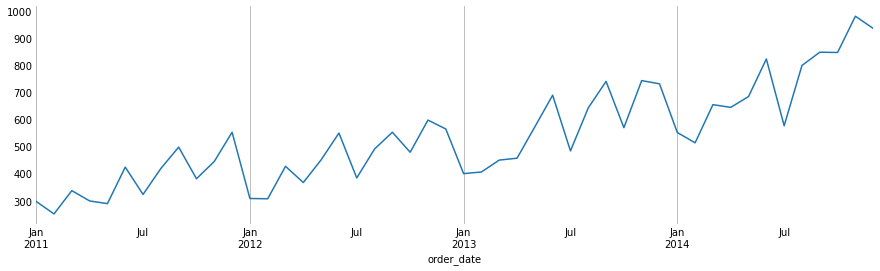

In [58]:
fig(15, 4)
plt.box(False)
aux['number_of_orders'].plot()
plt.grid(axis='x')
plt.tick_params(axis='both', which='both', length=0);

### Conversion Rate

How effective are our landing pages and calls-to-action? Do they just look pretty, or are they doing their job and encouraging more people to buy products?

---

We need more (and different) data to answer this one. 
        
            (conversions)
         number of purchases  / number of visits

### Repurchase Rate

> **Repurchase Rate has been growing, so increasings in sales is not totally due to new customers.**

Dividing the number of customers who made at least two purchases within a period by the total number of customers within that same period.

In [59]:
# monthly - number of customers who made at least two purchases
year = 2014
aux = df.loc[df['order_date_year'] == year, ['order_date','customer_id', 'order_id']]
customers_repurchases = aux.groupby([aux['order_date'].dt.month, 'customer_id'])['order_id'].nunique()

# one_purchase_customers = customers_repurchases.where(customers_repurchases == 1).dropna().reset_index()
# one_purchase_customers = one_purchase_customers.groupby('order_date')['customer_id'].nunique()

customers_repurchases = customers_repurchases.where(customers_repurchases > 1).dropna().reset_index()
customers_repurchases = customers_repurchases.groupby('order_date')['customer_id'].nunique()

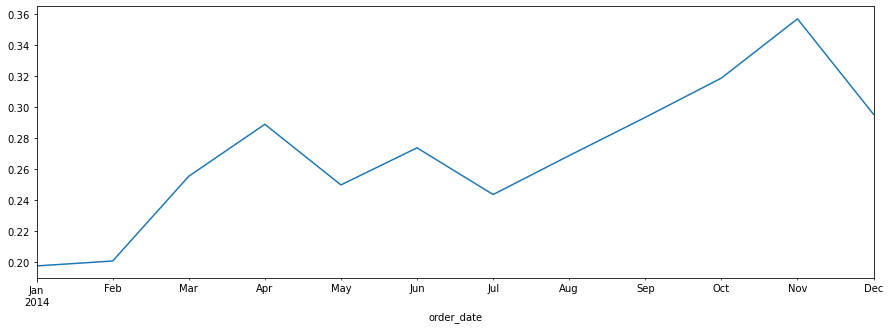

In [60]:
aux = df.loc[df['order_date_year'] == year, ['order_date','customer_id', 'order_id']]
aux.set_index('order_date', inplace=True)
total_customers = aux['customer_id'].resample("M").nunique() # Total number of customers per Month

d = {
    'repurchase_customers': customers_repurchases.values,
     'total_customers': total_customers.values,
}

repurchase = pd.DataFrame(d, index=total_customers.index)
repurchase['repurchase_rate'] = repurchase['repurchase_customers'] / repurchase['total_customers']
repurchase['repurchase_rate'].plot(figsize=(15,5));

In [61]:
# print(customers_repurchases+one_purchase_customers).values - total_customers.values # equals 0 

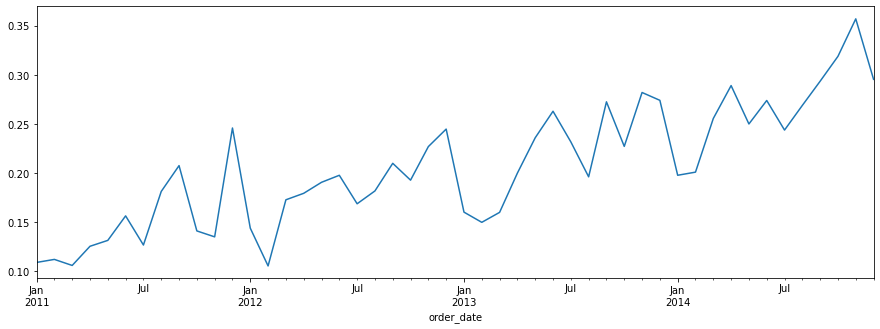

In [62]:
aux = df[['order_date','customer_id', 'order_id']]
customers_repurchases = aux.groupby([aux['order_date'].dt.year, aux['order_date'].dt.month, 'customer_id'])['order_id'].nunique()
customers_repurchases = customers_repurchases.where(customers_repurchases > 1).dropna().reset_index(level=[1,2])
customers_repurchases.index.name = "year"
customers_repurchases = customers_repurchases.reset_index('year')
customers_repurchases['order_date'] = pd.to_datetime(customers_repurchases.apply(lambda row: str(row['year']) +'/'+ str(row['order_date']), axis=1))
customers_repurchases = customers_repurchases.groupby('order_date')['customer_id'].nunique()

aux = df[['order_date','customer_id', 'order_id']]
aux.set_index('order_date', inplace=True)
total_customers = aux['customer_id'].resample("M").nunique() # Total number of customers per Month

d = {
    'repurchase_customers': customers_repurchases.values,
     'total_customers': total_customers.values,
}

repurchase = pd.DataFrame(d, index=total_customers.index)
repurchase['repurchase_rate'] = repurchase['repurchase_customers'] / repurchase['total_customers']
repurchase['repurchase_rate'].plot(figsize=(15,5));

## New Customers

> **Actually, less customers are coming, but as We just saw, the revenue growth rate is increasing**
>
> **as well as repurchase rate, so It's time to work on acquiring more customers.**

In [63]:
# 1590 customers, 25753 transations in 4 years of E-commerce
df['customer_id'].nunique(), df['order_id'].nunique()

(1590, 25753)

In [92]:
d = {
    'customer_ids':df.groupby([df["order_date"].dt.year, df["order_date"].dt.month])['customer_id'].unique().values,
    'date':df.groupby('order_date')['customer_id'].sum().resample('m').sum().index
}
ids_per_month = pd.DataFrame(d).set_index("date")
ids_per_month.head(2)

,customer_ids
date,
2011-01-31,"[TB-11280, JH-15985, AT-735, EM-14140, PO-1886..."
2011-02-28,"[MM-7260, ES-14080, KH-16630, EH-14185, EB-137..."


In [93]:
old_customers = []
d = {
    'months': [],
    'new_customers': [],
}

for index, ids in ids_per_month['customer_ids'].items():
    customer_count = 0
    for id_ in ids:
        if id_ not in old_customers:
            customer_count += 1
            old_customers.append(id_)
    d['months'].append(index.date()) 
    d['new_customers'].append(customer_count)
aux = pd.DataFrame(d)
aux['months'] = pd.to_datetime(aux['months']).dt.to_period('M')

aux['new_customers'].sum(), df['customer_id'].nunique()

(1590, 1590)

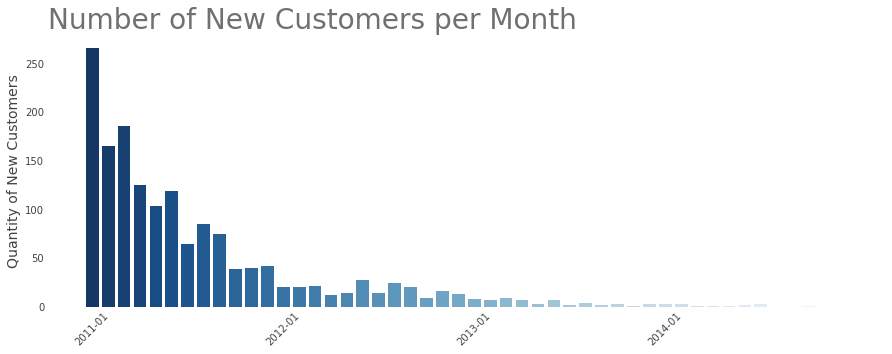

In [94]:
fig()
plt.box(False)
sns.barplot(data=aux, x="months", y='new_customers', palette="Blues_r")
plt.title(f"Number of New Customers per Month", fontsize=28, color='#707070', loc='left')
plt.tick_params(axis='both', which='both', length=0)
plt.xticks(rotation=45, color='#424242')
plt.yticks(color='#424242')
plt.xlabel("")
plt.ylabel("Quantity of New Customers", color='#424242', size=14)
plt.locator_params(axis='x', nbins=4);

In [95]:
aux['repurchase_rate'] = repurchase['repurchase_rate'].values
aux['total_customers'] = aux['new_customers'].cumsum()
aux.loc[:12]

,months,new_customers,repurchase_rate,total_customers
0,2011-01,266,0.109023,266
1,2011-02,165,0.112108,431
2,2011-03,186,0.105960,617
3,2011-04,125,0.125475,742
4,2011-05,103,0.131474,845
5,2011-06,119,0.156425,964
6,2011-07,64,0.126761,1028
7,2011-08,85,0.181287,1113
8,2011-09,75,0.207595,1188
9,2011-10,39,0.141104,1227


In [96]:
aux[aux['months'] == "2011-6"]['total_customers'] / aux['total_customers'].max()

5    0.606289
Name: total_customers, dtype: float64

**In the half of the first year of e-commerce We already had 60% of our current customers**

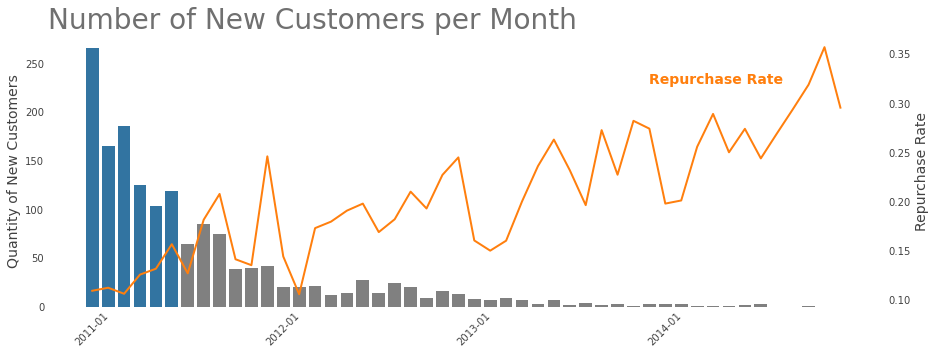

In [99]:
blue = '#1f77b4'; colors = []
for i in range(6): colors.append(blue)
for i in range(12*4-6): colors.append('grey')

fig()
plt.box(False)
sns.barplot(data=aux, x="months", y='new_customers', palette=colors)
plt.title(f"Number of New Customers per Month", fontsize=28, color='#707070', loc='left')
plt.tick_params(axis='both', which='both', length=0)
plt.xticks(rotation=45, color='#424242')
plt.yticks(color='#424242')
plt.xlabel("")
plt.ylabel("Quantity of New Customers", color='#424242', size=14)
plt.locator_params(axis='x', nbins=4)


ax2 = plt.twinx()
plt.box(False)
sns.lineplot(data=aux.set_index("months")['repurchase_rate'].values, ax=ax2, linewidth=2, color="#ff7f0e")
plt.tick_params(axis='both', which='both', length=0)
plt.yticks(color='#424242')
plt.ylabel("Repurchase Rate", color='#424242', size=14)
plt.text(35, .32, "Repurchase Rate", color="#ff7f0e", size=14, weight='bold');

## Purchase Frequency

Average number of orders per customer.

        Number of orders / Number of Unique Customers

> **Purchase Frequency is also increasing.**

In [70]:
def _purchase_frequency(df, year, monthly=False):
    if monthly:
        aux = pd.DataFrame()
        aux['order_id'] = df[df['order_date_year'] == year].groupby(df["order_date"].dt.month)[['order_id']].nunique() 
        aux['customer_id'] = df[df['order_date_year'] == year].groupby(df["order_date"].dt.month)[['customer_id']].nunique()
        aux.index = pd.date_range(start=f'1/1/{year}', end=f'1/1/{year+1}', freq='m')
        aux['purchase_frequency'] = aux['order_id'] / aux['customer_id']
        return aux#[['purchase_frequency']]
    else:
        return df[df['order_date_year'] == year]['order_id'].nunique() / df[df['order_date_year'] == year]['customer_id'].nunique()

In [71]:
_purchase_frequency(df, 2011), _purchase_frequency(df, 2012), _purchase_frequency(df, 2013), _purchase_frequency(df, 2014)

(3.4499618029029793, 3.9912600145666426, 4.725651577503429, 5.8682991396426205)

In [72]:
print( _purchase_frequency(df, 2011, monthly=True)['purchase_frequency'].mean() )
print( _purchase_frequency(df, 2012, monthly=True)['purchase_frequency'].mean() )
print( _purchase_frequency(df, 2013, monthly=True)['purchase_frequency'].mean() )
print( _purchase_frequency(df, 2014, monthly=True)['purchase_frequency'].mean() )

1.1727914533654307
1.222097001582492
1.2678773824452818
1.3472079599799027


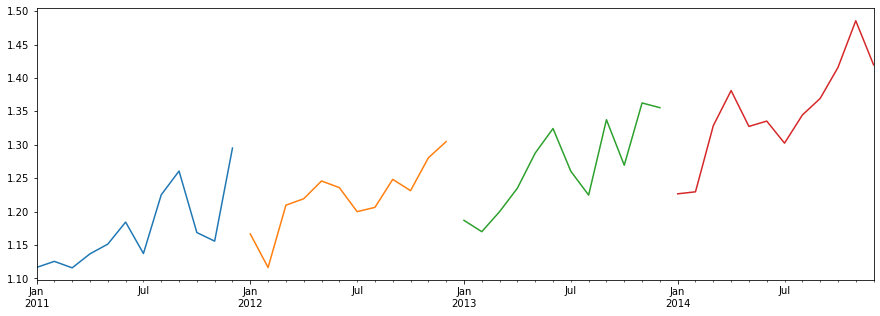

In [73]:
_purchase_frequency(df, 2011, monthly=True)['purchase_frequency'].plot(figsize=(15, 5));
_purchase_frequency(df, 2012, monthly=True)['purchase_frequency'].plot(figsize=(15, 5));
_purchase_frequency(df, 2013, monthly=True)['purchase_frequency'].plot(figsize=(15, 5));
_purchase_frequency(df, 2014, monthly=True)['purchase_frequency'].plot(figsize=(15, 5));

2014 

        Annual Purchase Frequency - 5.86
                          Monthly - 1.34
                          
This happens due to Repurchases. Look at the number of customer ids

In [74]:
_purchase_frequency(df, 2014, monthly=True).sum() 

order_id              8868.000000
customer_id           6539.000000
purchase_frequency      16.166496
dtype: float64

We don't have 6539 customers   

In [75]:
df[df['order_date_year'] == year]['order_id'].nunique(), df[df['order_date_year'] == year]['customer_id'].nunique()

(8867, 1511)

In [76]:
year=2014
print('Orders - Customers')
for year in [2011, 2012, 2013, 2014]:
    print("",df[df['order_date_year'] == year]['order_id'].nunique()," "*4, df[df['order_date_year'] == year]['customer_id'].nunique())

Orders - Customers
 4516      1309
 5480      1373
 6890      1458
 8867      1511


**Number of orders almost doubled** 

In [77]:
(8531-4440) / 4440

0.9213963963963964

**While the number of customers only increased by 15%**

In [78]:
(1511-1309) / 1309

0.15431627196333078

### Average Order Value

> 243

In [79]:
def _avg_order_value(df, year, monthly=False):
    if monthly:
        aux = df[df['order_date_year'] == year].groupby([df['order_date'].dt.month, 'order_id'])[['sales']].mean().reset_index()
        aux = aux.groupby("order_date")[['sales']].mean()
        aux.index = pd.date_range(start=f'1/1/{year}', end=f'1/1/{year+1}', freq='m')
        aux.columns = ['avg_sales']
        return aux
    else:
        return df[df['order_date_year'] == year].groupby('order_id')['sales'].mean().mean()

In [80]:
_avg_order_value(df, 2011), _avg_order_value(df, 2012), _avg_order_value(df, 2013), _avg_order_value(df, 2014),

(247.51068225782092, 243.86703857323147, 248.23488341025168, 243.4390042072188)

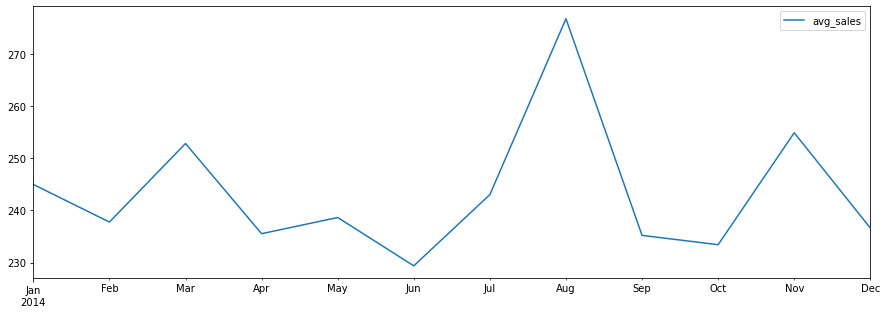

In [81]:
_avg_order_value(df, 2014, True).plot(figsize=(15, 5));

### Number of Active Customers

We'll consider a customer as active if they have made a purchase within a 12 months time period.

In [82]:
years = [2011, 2012, 2013, 2014]

active_days_threshold = 365

aux = (pd.to_datetime(f'{years[-1]+1}-01-01') - df[df['order_date_year'].isin(years)].groupby("customer_id")['order_date'].max()).dt.days
aux.where(aux < active_days_threshold).count() / len(aux)

0.950314465408805

In [83]:
active_df = pd.DataFrame(aux)
active_df['active'] = aux.where(aux < active_days_threshold).apply(lambda x: True if x>=0 else False)

In [84]:
active_df.reset_index().to_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', f'active_customers_{years[-1]}.csv']), index=False)

Saving for Dashboard

In [85]:
active_customers = pd.DataFrame(columns=['customer_id','order_date','active', 'year'])
for year in years:
    aux_df = pd.read_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', f'active_customers_{year}.csv']))
    aux_df['year'] = year
    active_customers = pd.concat([active_customers, aux_df])

In [86]:
active_customers[['active']].to_parquet(join_paths([directory.DATA_DIR, 'processed', 'active_customers.parquet']))
active_customers.reset_index().to_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', f'active_customers.csv']), index=False)

### Churn Rate

Let's assume that a customer is a Churn when they have gone 6 months without purchasing.

> **14%**

In [87]:
years = [2011, 2012, 2013, 2014]
month_threshold = 6
churn_days_threshold = 30 * month_threshold

aux = (pd.to_datetime(f'{years[-1]+1}-01-01') - df[df['order_date_year'].isin(years)].groupby("customer_id")['order_date'].max()).dt.days
aux.name = 'recency'
aux.where(aux > churn_days_threshold).count() / len(aux)

0.14276729559748427

In [88]:
churn_df = pd.DataFrame(aux)
churn_df['churn'] = aux.where(aux > churn_days_threshold).apply(lambda x: True if x>=0 else False)

In [89]:
churn_df.reset_index().to_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', f'churned_customers_{years[-1]}.csv']), index=False)

Saving for Dashboard

In [90]:
churned_customers = pd.DataFrame(columns=['customer_id','recency','churn', 'year'])
for year in years:
    aux_df = pd.read_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', f'churned_customers_{year}.csv']))
    aux_df['year'] = year
    churned_customers = pd.concat([churned_customers, aux_df])

In [91]:
churned_customers[['churn']].to_parquet(join_paths([directory.DATA_DIR, 'processed', 'churned_customers.parquet']))
churned_customers.reset_index().to_csv(join_paths([directory.DATA_DIR, 'processed', 'dashboard', f'churned_customers.csv']), index=False)

## Power BI Dashboard

Total Sales <br>
Revenue Growth Rate<br>
Number of Orders <br>

**KPIs:**
 - Average Order Value
 - Average Profit Per Customer
 - Active Customers Rate
 - Churn Rate
 
<br> 

_Light Theme:_

![img](../images/dashboard_light_theme.PNG)

_Dark Theme:_

![img](../images/dashboard_dark_theme.PNG)


### Why?

<br>

**Total Sales**
        
        How much money our business makes from all the products and services sold.
        It tells us exactly how much money our business generates before expenses.



**Revenue Growth Rate**

        It measures the month-over-month percentage increase in revenue
        and provides a solid indicator of how quickly the company is growing.


        
**Number of Orders**

        It represents an indicator of our ability to generate sales opportunities.
        When analyzed in the context of Active Customers, the Number of Orders provides an 
        indicator of our ability to attract recurring purchases and also the effectiveness
        of our targeted advertising.



**Average Order Value**

        Average amount of money a customer spends per transaction. 
        It’s a key KPI because it helps measure how well We capitalize on cross-selling and
        upselling opportunities.
        
        Increasing average order value is one of the most efficient ways to increase ecommerce
        revenue. And, generally, the higher the AOV, the more We can spend to acquire a new customer.
                
        
        
**Average Profit Per Customer**

        The more profit We can get out of a customer, the more We can afford to spend on acquiring 
        a customer or even reinvesting in other areas of the company.. 

        “For example, if each customer on average is worth 1,000 to you, you can afford to spend 
        anything below 1,000 to be profitable. Whereas if a competitor’s average profit per customer
        is only 200, they can’t spend anything above 200, but you can because each customer is worth more.”
        
        
        
**Active Customers Rate**

        The point behind tracking active users is to make sure that the product is providing
        continuing value to users.



**Churn rate**

        It provides clarity on how well the business is retaining customers, which is a reflection
        on the quality of the service the business is providing, as well as its usefulness.
        
        
[_E-commerce KPIs_](https://databox.com/ecommerce-kpis)


## Sales forecast

&emsp;[Github - Sales forecast](https://github.com/pauloreis-ds/e_mart_retailer/tree/main/project_sales_forecast)


## Country Segmentation

&emsp;[Github - Country Segmentation](https://github.com/pauloreis-ds/e_mart_retailer/tree/main/project_country_segmentation)

## Next Steps

Possible Paths

&emsp;Customer Segmentation<br>
&emsp;Customer Life Time Value<br>
&emsp;Detection of Churn (predict)<br>
&emsp;Market Basket Analysis<br>